✅ Phase Transition found at Tc = 627.06 K
📊 Plot saved to 'phase_diagram_plot.png'


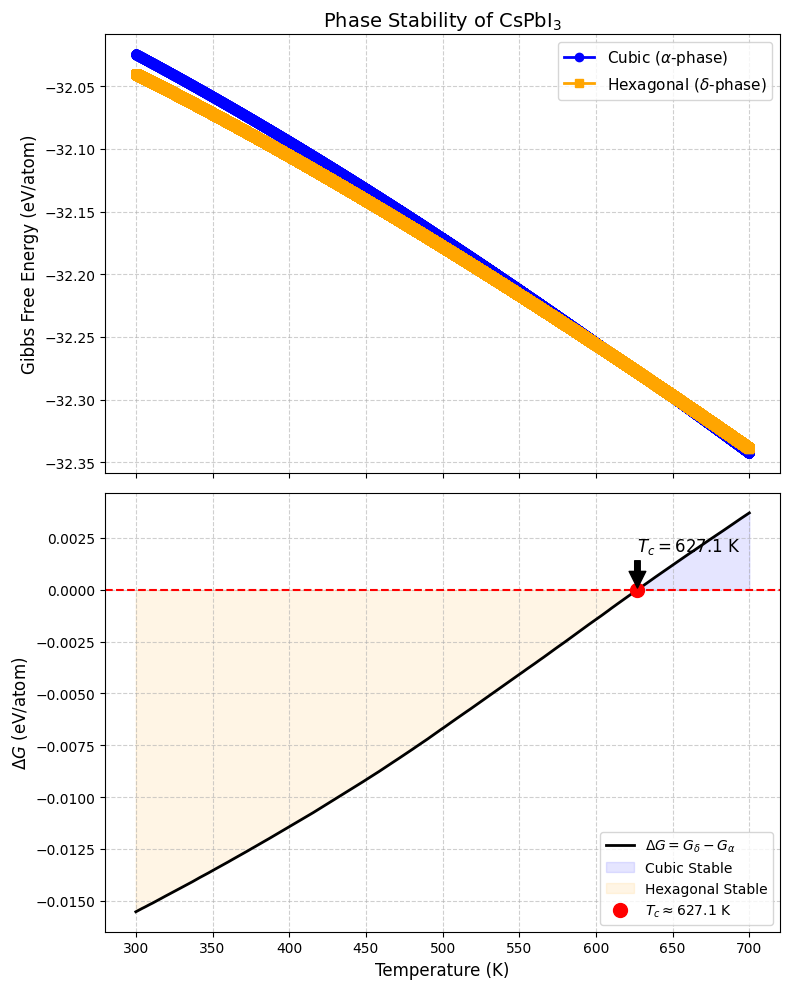

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

# --- CONFIGURATION ---
FILE_CUBIC = "rs_free_energy_cubic.csv"
FILE_DELTA = "rs_free_energy_delta.csv"

def load_data(filename):
    """
    Robust CSV loader. Assumes columns are [Temperature, FreeEnergy, ...]
    If headers are missing, it assumes 1st col = T, 2nd col = G.
    """
    try:
        # Try reading with headers inferred
        df = pd.read_csv(filename, sep=r'\s+|,', engine='python')
        
        # Clean up column names (strip whitespace)
        df.columns = df.columns.str.strip()
        
        # Identify T and G columns automatically if possible
        t_col = [c for c in df.columns if 'temp' in c.lower() or 'T' in c]
        g_col = [c for c in df.columns if 'free' in c.lower() or 'energy' in c.lower() or 'G' in c]
        
        if t_col and g_col:
            return df[t_col[0]].values, df[g_col[0]].values
        else:
            # Fallback: Assume 1st and 2nd columns
            return df.iloc[:, 0].values, df.iloc[:, 1].values
            
    except Exception as e:
        print(f"Error reading {filename}: {e}")
        return None, None

def find_crossing_point(T, G1, G2):
    """ Finds the temperature where G1 and G2 cross (Delta G = 0). """
    diff = G2 - G1
    # Create an interpolation function for the difference
    f_diff = interp1d(T, diff, kind='cubic')
    
    # Scan for zero crossing
    t_fine = np.linspace(T.min(), T.max(), 5000)
    diff_fine = f_diff(t_fine)
    
    # Find indices where sign changes
    signs = np.sign(diff_fine)
    zero_crossings = np.where(np.diff(signs))[0]
    
    if len(zero_crossings) > 0:
        # Take the first crossing
        idx = zero_crossings[0]
        # Linear interpolation between the two points for precision
        t1, t2 = t_fine[idx], t_fine[idx+1]
        d1, d2 = diff_fine[idx], diff_fine[idx+1]
        t_cross = t1 + (0 - d1) * (t2 - t1) / (d2 - d1)
        return t_cross
    return None

# --- MAIN PLOTTING ---
def main():
    # 1. Load Data
    T_cub, G_cub = load_data(FILE_CUBIC)
    T_del, G_del = load_data(FILE_DELTA)
    
    if T_cub is None or T_del is None:
        print("Could not load data. Check file names and format.")
        return

    # Ensure temperatures match (or interpolate if needed)
    if not np.allclose(T_cub, T_del):
        print("⚠️ Warning: Temperature grids do not match exactly. Interpolating Delta to Cubic grid...")
        f_del = interp1d(T_del, G_del, kind='linear', fill_value="extrapolate")
        G_del = f_del(T_cub)
        T_del = T_cub

    # 2. Calculate Difference
    Delta_G = G_del - G_cub # If negative, Delta is stable. If positive, Cubic is stable.
    
    # 3. Find Transition Temperature
    Tc = find_crossing_point(T_cub, G_cub, G_del)

    # --- PLOT Setup ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

    # Subplot 1: Absolute Free Energies
    ax1.plot(T_cub, G_cub, 'o-', color='blue', label=r'Cubic ($\alpha$-phase)', markersize=6, linewidth=2)
    ax1.plot(T_del, G_del, 's-', color='orange', label=r'Hexagonal ($\delta$-phase)', markersize=6, linewidth=2)
    
    ax1.set_ylabel(r"Gibbs Free Energy (eV/atom)", fontsize=12)
    ax1.set_title("Phase Stability of CsPbI$_3$", fontsize=14)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend(fontsize=11)

    # Subplot 2: Delta G (The Stability Criterion)
    ax2.plot(T_cub, Delta_G, 'k-', linewidth=2, label=r'$\Delta G = G_{\delta} - G_{\alpha}$')
    
    # Fill regions
    ax2.fill_between(T_cub, 0, Delta_G, where=(Delta_G > 0), color='blue', alpha=0.1, label="Cubic Stable")
    ax2.fill_between(T_cub, 0, Delta_G, where=(Delta_G < 0), color='orange', alpha=0.1, label="Hexagonal Stable")
    
    ax2.axhline(0, color='red', linestyle='--', linewidth=1.5)
    
    if Tc:
        ax2.plot(Tc, 0, 'ro', markersize=10, label=f'$T_c \\approx {Tc:.1f}$ K')
        ax2.annotate(f"$T_c = {Tc:.1f}$ K", xy=(Tc, 0), xytext=(Tc, max(Delta_G)*0.5),
                     arrowprops=dict(facecolor='black', shrink=0.05), fontsize=12)
        print(f"✅ Phase Transition found at Tc = {Tc:.2f} K")
    else:
        print("ℹ️ No phase transition found in this temperature range.")

    ax2.set_ylabel(r"$\Delta G$ (eV/atom)", fontsize=12)
    ax2.set_xlabel("Temperature (K)", fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend(loc='best')

    plt.tight_layout()
    plt.savefig("phase_diagram_plot.png", dpi=300)
    print("📊 Plot saved to 'phase_diagram_plot.png'")
    plt.show()

if __name__ == "__main__":
    main()

ℹ️  Detected Total Energy in Cubic file (Avg ~ -32.2 eV).
    -> Normalizing by N=1080 to get eV/atom.
ℹ️  Detected Total Energy in Delta file (Avg ~ -32.2 eV).
    -> Normalizing by N=1080 to get eV/atom.

✅ TRANSITION TEMPERATURE FOUND: 627.06 K
📊 Plot saved to 'phase_diagram_plot.png'


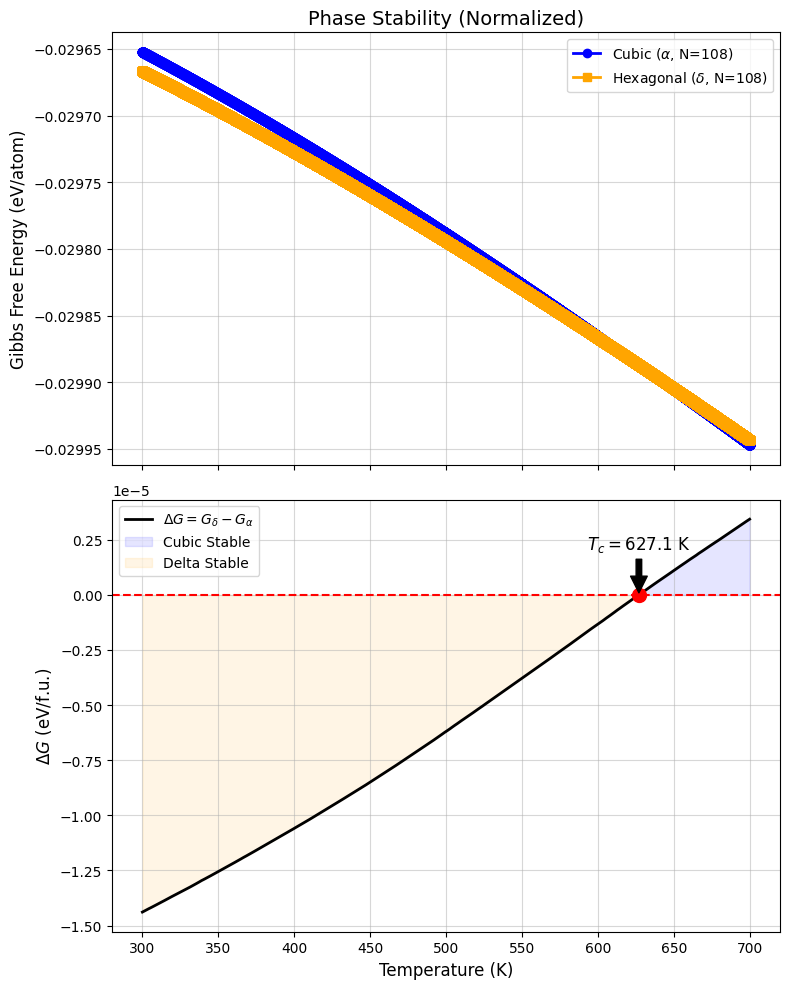

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

# --- CONFIGURATION ---
FILE_CUBIC = "rs_free_energy_cubic.csv"
FILE_DELTA = "rs_free_energy_delta.csv"

# [CRITICAL] Atom counts for normalization
# If your CSV already contains eV/atom, set these to 1.
# If your CSV contains TOTAL Free Energy, set these to your system size (e.g., 108).
N_ATOMS_CUBIC = 1080  
N_ATOMS_DELTA = 1080

def load_data(filename):
    """
    Robust CSV loader. Returns Temperature and Free Energy arrays.
    """
    try:
        df = pd.read_csv(filename, sep=r'\s+|,', engine='python')
        df.columns = df.columns.str.strip()
        
        # Auto-detect columns
        t_col = [c for c in df.columns if 'temp' in c.lower() or 'T' in c]
        g_col = [c for c in df.columns if 'free' in c.lower() or 'energy' in c.lower() or 'G' in c]
        
        if t_col and g_col:
            return df[t_col[0]].values, df[g_col[0]].values
        else:
            # Fallback: Assume Col 0 is T, Col 1 is G
            return df.iloc[:, 0].values, df.iloc[:, 1].values
            
    except Exception as e:
        print(f"Error reading {filename}: {e}")
        return None, None

def find_crossing_point(T, G1, G2):
    """ Finds Tc where Delta G = 0 """
    diff = G2 - G1
    f_diff = interp1d(T, diff, kind='cubic')
    t_fine = np.linspace(T.min(), T.max(), 5000)
    diff_fine = f_diff(t_fine)
    
    # Find sign changes
    zero_crossings = np.where(np.diff(np.sign(diff_fine)))[0]
    
    if len(zero_crossings) > 0:
        idx = zero_crossings[0]
        t1, t2 = t_fine[idx], t_fine[idx+1]
        d1, d2 = diff_fine[idx], diff_fine[idx+1]
        # Linear interpolation for precise crossing
        t_cross = t1 + (0 - d1) * (t2 - t1) / (d2 - d1)
        return t_cross
    return None

def main():
    # 1. Load Data
    T_cub, G_cub = load_data(FILE_CUBIC)
    T_del, G_del = load_data(FILE_DELTA)
    
    if T_cub is None or T_del is None: return

    # 2. AUTO-NORMALIZATION CHECK
    # Solid energies are typically -2 to -10 eV/atom.
    # If energy is < -50 eV, it's likely TOTAL energy.
    
    if np.mean(G_cub) < -20 and N_ATOMS_CUBIC > 1:
        print(f"ℹ️  Detected Total Energy in Cubic file (Avg ~ {np.mean(G_cub):.1f} eV).")
        print(f"    -> Normalizing by N={N_ATOMS_CUBIC} to get eV/atom.")
        G_cub = G_cub / N_ATOMS_CUBIC
        
    if np.mean(G_del) < -20 and N_ATOMS_DELTA > 1:
        print(f"ℹ️  Detected Total Energy in Delta file (Avg ~ {np.mean(G_del):.1f} eV).")
        print(f"    -> Normalizing by N={N_ATOMS_DELTA} to get eV/atom.")
        G_del = G_del / N_ATOMS_DELTA

    # Align Grids if needed
    if not np.allclose(T_cub, T_del):
        print("⚠️  Interpolating Delta data to match Cubic temperature grid...")
        f_del = interp1d(T_del, G_del, kind='linear', fill_value="extrapolate")
        G_del = f_del(T_cub)
        T_del = T_cub # Now they match

    # 3. Calculate Delta G
    Delta_G = G_del - G_cub
    Tc = find_crossing_point(T_cub, G_cub, G_del)

    # --- PLOTTING ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

    # Plot 1: Absolute G
    ax1.plot(T_cub, G_cub, 'o-', color='blue', label=r'Cubic ($\alpha$, N=108)', lw=2)
    ax1.plot(T_del, G_del, 's-', color='orange', label=r'Hexagonal ($\delta$, N=108)', lw=2)
    ax1.set_ylabel("Gibbs Free Energy (eV/atom)", fontsize=12)
    ax1.set_title("Phase Stability (Normalized)", fontsize=14)
    ax1.grid(True, alpha=0.5)
    ax1.legend()

    # Plot 2: Delta G
    ax2.plot(T_cub, Delta_G, 'k-', lw=2, label=r'$\Delta G = G_{\delta} - G_{\alpha}$')
    ax2.fill_between(T_cub, 0, Delta_G, where=(Delta_G>0), color='blue', alpha=0.1, label="Cubic Stable")
    ax2.fill_between(T_cub, 0, Delta_G, where=(Delta_G<0), color='orange', alpha=0.1, label="Delta Stable")
    ax2.axhline(0, color='red', ls='--')

    if Tc:
        ax2.plot(Tc, 0, 'ro', ms=10)
        ax2.annotate(f"$T_c = {Tc:.1f}$ K", xy=(Tc, 0), xytext=(Tc, max(Delta_G)*0.6),
                     arrowprops=dict(facecolor='black', shrink=0.05), ha='center', fontsize=12)
        print(f"\n✅ TRANSITION TEMPERATURE FOUND: {Tc:.2f} K")
    
    ax2.set_ylabel(r"$\Delta G$ (eV/f.u.)", fontsize=12)
    ax2.set_xlabel("Temperature (K)", fontsize=12)
    ax2.grid(True, alpha=0.5)
    ax2.legend()

    plt.tight_layout()
    plt.savefig("phase_diagram_plot.png", dpi=300)
    print("📊 Plot saved to 'phase_diagram_plot.png'")
    plt.show()

if __name__ == "__main__":
    main()

In [1]:
import sys
import os
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from matplotlib import rcParams

# Use 'Agg' backend for non-interactive plotting
matplotlib.use('Agg')

# -----------------------------------------------------------------------------
# 1. PRX / PUBLICATION PLOT STYLE SETTINGS
# -----------------------------------------------------------------------------
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Tahoma'] 

matplotlib.rcParams.update({
    'font.size': 12,             
    'text.usetex': True,         
    'axes.labelsize': 14,        
    'xtick.labelsize': 12,       
    'ytick.labelsize': 12,       
    'legend.fontsize': 11,       
    'axes.linewidth': 1.0,       
    'xtick.direction': 'in',     
    'ytick.direction': 'in',     
    'xtick.major.size': 5,       
    'ytick.major.size': 5,       
    'xtick.minor.size': 2.5,     
    'ytick.minor.size': 2.5,     
    'xtick.top': True,           
    'ytick.right': True,         
    'legend.frameon': False,     
    'savefig.dpi': 300,          
    'figure.figsize': (6, 8),    # Taller figure for 2 subplots
    'grid.linestyle': '--',      
    'grid.alpha': 0.5,           
    'lines.linewidth': 2,        
    'axes.edgecolor': '0.1',     
})

# LaTeX preamble (Requires a local LaTeX installation)
matplotlib.rcParams['text.latex.preamble'] = '\n'.join([
    r'\usepackage{siunitx}',     
    r'\sisetup{detect-all}',     
    r'\usepackage{amsmath, amssymb}', 
])

# -----------------------------------------------------------------------------
# 2. CONFIGURATION & COLORS
# -----------------------------------------------------------------------------
FILE_CUBIC = "rs_free_energy_cubic.csv"
FILE_DELTA = "rs_free_energy_delta.csv"

# Colors matching the style
COLOR_CUBIC = '#5DA5DA'  # Blue
COLOR_DELTA = '#F15854'  # Red/Orange
COLOR_BLACK = '#4D4D4D'

# [CRITICAL] Atom counts for normalization
N_ATOMS_CUBIC = 1080  
N_ATOMS_DELTA = 1080

# -----------------------------------------------------------------------------
# 3. DATA PROCESSING LOGIC
# -----------------------------------------------------------------------------
def load_data(filename):
    """
    Robust CSV loader. Returns Temperature and Free Energy arrays.
    """
    try:
        if not os.path.exists(filename):
            print(f"Error: File '{filename}' not found.")
            return None, None

        df = pd.read_csv(filename, sep=r'\s+|,', engine='python')
        df.columns = df.columns.str.strip()
        
        # Auto-detect columns
        t_col = [c for c in df.columns if 'temp' in c.lower() or 'T' in c]
        g_col = [c for c in df.columns if 'free' in c.lower() or 'energy' in c.lower() or 'G' in c]
        
        if t_col and g_col:
            return df[t_col[0]].values, df[g_col[0]].values
        else:
            # Fallback: Assume Col 0 is T, Col 1 is G
            return df.iloc[:, 0].values, df.iloc[:, 1].values
            
    except Exception as e:
        print(f"Error reading {filename}: {e}")
        return None, None

def find_crossing_point(T, G1, G2):
    """ Finds Tc where Delta G = 0 """
    diff = G2 - G1
    f_diff = interp1d(T, diff, kind='cubic')
    
    # Create fine grid for precise root finding
    t_fine = np.linspace(T.min(), T.max(), 5000)
    diff_fine = f_diff(t_fine)
    
    # Find sign changes
    zero_crossings = np.where(np.diff(np.sign(diff_fine)))[0]
    
    if len(zero_crossings) > 0:
        idx = zero_crossings[0]
        t1, t2 = t_fine[idx], t_fine[idx+1]
        d1, d2 = diff_fine[idx], diff_fine[idx+1]
        # Linear interpolation for precise crossing between grid points
        t_cross = t1 + (0 - d1) * (t2 - t1) / (d2 - d1)
        return t_cross
    return None

def main():
    # 1. Load Data
    print("--- Loading Phase Data ---")
    T_cub, G_cub = load_data(FILE_CUBIC)
    T_del, G_del = load_data(FILE_DELTA)
    
    if T_cub is None or T_del is None: 
        return

    # 2. AUTO-NORMALIZATION CHECK
    # Solid energies are typically -2 to -10 eV/atom.
    # If energy is < -50 eV, it's likely TOTAL energy.
    
    if np.mean(G_cub) < -20 and N_ATOMS_CUBIC > 1:
        print(f"ℹ️  Detected Total Energy in Cubic file (Avg ~ {np.mean(G_cub):.1f} eV).")
        print(f"    -> Normalizing by N={N_ATOMS_CUBIC} to get eV/atom.")
        G_cub = G_cub / N_ATOMS_CUBIC
        
    if np.mean(G_del) < -20 and N_ATOMS_DELTA > 1:
        print(f"ℹ️  Detected Total Energy in Delta file (Avg ~ {np.mean(G_del):.1f} eV).")
        print(f"    -> Normalizing by N={N_ATOMS_DELTA} to get eV/atom.")
        G_del = G_del / N_ATOMS_DELTA

    # Align Grids if needed (Interpolate Delta onto Cubic grid)
    if not np.allclose(T_cub, T_del):
        print("⚠️  Interpolating Delta data to match Cubic temperature grid...")
        f_del = interp1d(T_del, G_del, kind='linear', fill_value="extrapolate")
        G_del = f_del(T_cub)
        T_del = T_cub # Now they match

    # 3. Calculate Delta G
    # Delta G = G_delta - G_cubic (Positive means Cubic is stable, Negative means Delta is stable)
    Delta_G = G_del - G_cub
    Tc = find_crossing_point(T_cub, G_cub, G_del)

    # -----------------------------------------------------------------------------
    # 4. PLOTTING
    # -----------------------------------------------------------------------------
    print("--- Generating Plot ---")
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
    
    # Reduce whitespace between subplots
    plt.subplots_adjust(hspace=0.05)

    # --- Plot 1: Absolute G ---
    # We subtract a baseline to make the plot readable if numbers are huge, 
    # but here we plot absolute eV/atom.
    
    ax1.plot(T_cub, G_cub, 'o-', color=COLOR_CUBIC, label=r'Cubic ($\alpha$)', 
             markevery=10, markersize=5, markerfacecolor='white', markeredgewidth=1.5)
    ax1.plot(T_del, G_del, 's-', color=COLOR_DELTA, label=r'Hexagonal ($\delta$)', 
             markevery=10, markersize=5, markerfacecolor='white', markeredgewidth=1.5)
    
    ax1.set_ylabel(r'$G$ [\si{\electronvolt}/atom]')
    # ax1.set_title(r'\textbf{Phase Stability Analysis}') # Bold LaTeX title
    ax1.grid(True)
    ax1.legend(loc='best')

    # --- Plot 2: Delta G ---
    ax2.plot(T_cub, Delta_G, '-', color=COLOR_BLACK, lw=2, label=r'$\Delta G = G_{\delta} - G_{\alpha}$')
    
    # Fill areas
    # If Delta G > 0: G_delta > G_cubic -> Cubic is stable (Blue)
    ax2.fill_between(T_cub, 0, Delta_G, where=(Delta_G >= 0), 
                     color=COLOR_CUBIC, alpha=0.15, label=r'Cubic Stable')
    
    # If Delta G < 0: G_delta < G_cubic -> Delta is stable (Red)
    ax2.fill_between(T_cub, 0, Delta_G, where=(Delta_G <= 0), 
                     color=COLOR_DELTA, alpha=0.15, label=r'Hexagonal Stable')
    
    # Zero line
    ax2.axhline(0, color='black', ls=':', lw=1)

    # Annotate Tc
    if Tc:
        # Plot point
        ax2.plot(Tc, 0, 'o', color='white', markeredgecolor='black', markeredgewidth=1.5, markersize=8, zorder=10)
        
        # Add annotation with LaTeX formatting
        ax2.annotate(r'$T_c \approx \SI{' + f"{Tc:.0f}" + r'}{\kelvin}$', 
                     xy=(Tc, 0), 
                     xytext=(Tc, max(np.abs(Delta_G))*0.5),
                     arrowprops=dict(arrowstyle='->', color='black', lw=1),
                     ha='center', fontsize=12, 
                     bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8))
        print(f"\n✅ TRANSITION TEMPERATURE FOUND: {Tc:.2f} K")
    
    ax2.set_ylabel(r'$\Delta G$ [\si{\electronvolt}/atom]')
    ax2.set_xlabel(r'Temperature [\si{\kelvin}]')
    ax2.grid(True)
    
    # Combine legends for the bottom plot if needed, or just rely on fills
    # ax2.legend(loc='lower left')

    # Save
    output_filename = "phase_diagram_plot.png"
    plt.savefig(output_filename, format='png', dpi=600, bbox_inches='tight')
    plt.savefig(output_filename.replace('.png', '.pdf'), format='pdf', dpi=600, bbox_inches='tight')
    print(f"📊 Plot saved to '{output_filename}' and PDF.")

if __name__ == "__main__":
    main()

--- Loading Phase Data ---
ℹ️  Detected Total Energy in Cubic file (Avg ~ -32.2 eV).
    -> Normalizing by N=1080 to get eV/atom.
ℹ️  Detected Total Energy in Delta file (Avg ~ -32.2 eV).
    -> Normalizing by N=1080 to get eV/atom.
--- Generating Plot ---

✅ TRANSITION TEMPERATURE FOUND: 544.21 K
📊 Plot saved to 'phase_diagram_plot.png' and PDF.
